In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [15]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 48.7MB/s]


In [20]:
class MultiHeadLinearAttention(nn.Module):
    def __init__(self, patch_size=4, hidden_dim=128, num_heads=8, num_classes=10):
        super().__init__()
        self.patch_size = patch_size
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        patch_dim = patch_size * patch_size * 3

        self.patch_embed = nn.Linear(patch_dim, hidden_dim)

        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        P = self.patch_size
        num_patches_h = H // P
        num_patches_w = W // P

        x = x.unfold(2, P, P).unfold(3, P, P)
        x = x.contiguous().view(B, C, -1, P*P)
        x = x.permute(0, 2, 1, 3).contiguous().view(B, -1, C * P * P)

        x = self.patch_embed(x)

        B, T, C = x.shape
        H = self.num_heads
        D = self.head_dim

        Q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        K = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        V = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        Q = F.normalize(Q, p=2, dim=-1)
        K = F.normalize(K, p=2, dim=-1)

        KV = torch.einsum('b h t d, b h t e -> b h d e', K, V)
        out = torch.einsum('b h t d, b h d e -> b h t e', Q, KV)

        out = out.transpose(1, 2).contiguous().view(B, T, C)

        out = out.mean(dim=1)
        return self.classifier(out)


class DeepTransformer(nn.Module):
    def __init__(self, patch_size=4, hidden_dim=128, num_heads=8, num_layers=4, num_classes=10):
        super().__init__()
        self.patch_size = patch_size
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.num_layers = num_layers

        patch_dim = patch_size * patch_size * 3
        num_patches = (32 // patch_size) ** 2
        self.num_patches = num_patches

        self.patch_embed = nn.Linear(patch_dim, hidden_dim)
        self.pos_encoding = nn.Parameter(torch.randn(1, num_patches, hidden_dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape
        P = self.patch_size

        x = x.unfold(2, P, P).unfold(3, P, P)
        x = x.contiguous().view(B, C, -1, P*P)
        x = x.permute(0, 2, 1, 3).contiguous().view(B, -1, C * P * P)

        x = self.patch_embed(x)
        x = x + self.pos_encoding

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        x = self.transformer(x)
        x = self.norm(x)

        return self.classifier(x[:, 0, :])


class ResNetBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.resnet = torchvision.models.resnet18(weights=None)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()
        self.resnet.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        return self.resnet(x)

In [17]:
def evaluate_accuracy(model, testloader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    model.train()
    return accuracy_score(all_targets, all_preds)


def train_model(model, trainloader, testloader, epochs, name, learning_rate=0.001):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []
    epoch_list = []
    epoch_times = []

    start = time.time()

    for epoch in tqdm(range(epochs), desc=name):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        epoch_times.append(time.time() - epoch_start)

        if epoch % 5 == 0 or epoch == epochs - 1:
            avg_loss = running_loss / len(trainloader)
            train_losses.append(avg_loss)

            acc = evaluate_accuracy(model, testloader, device)
            test_accuracies.append(acc)
            epoch_list.append(epoch)

            if epoch % 20 == 0 or epoch == epochs - 1:
                tqdm.write(f"{name} - Epoch {epoch}: Loss={avg_loss:.4f}, Test Acc={acc:.4f}")

    duration = time.time() - start
    best_acc = max(test_accuracies) if test_accuracies else 0.0
    avg_epoch_time = np.mean(epoch_times)

    print(f"\n{name:35} | Time: {duration:.2f}s | Avg/Epoch: {avg_epoch_time:.3f}s | Best Acc: {best_acc:.4f}")

    return train_losses, test_accuracies, epoch_list

In [ ]:
epochs = 10

models = {
    "Multi-Head Linear Attention": MultiHeadLinearAttention(patch_size=4, hidden_dim=128, num_heads=8, num_classes=10).to(device),
    "Deep Transformer (4 layers)": DeepTransformer(patch_size=4, hidden_dim=128, num_heads=8, num_layers=4, num_classes=10).to(device),
    "ResNet-18 (Baseline)": ResNetBaseline(num_classes=10).to(device)
}

results = {}

for name, model in models.items():
    print(f" Обучение: {name}")

    train_loss, test_acc, epochs_list = train_model(
        model, trainloader, testloader, epochs, name, learning_rate=0.001
    )

    results[name] = {
        'train_loss': train_loss,
        'test_accuracy': test_acc,
        'epochs': epochs_list
    }

/tmp/ipykernel_5950/885153229.py:46: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


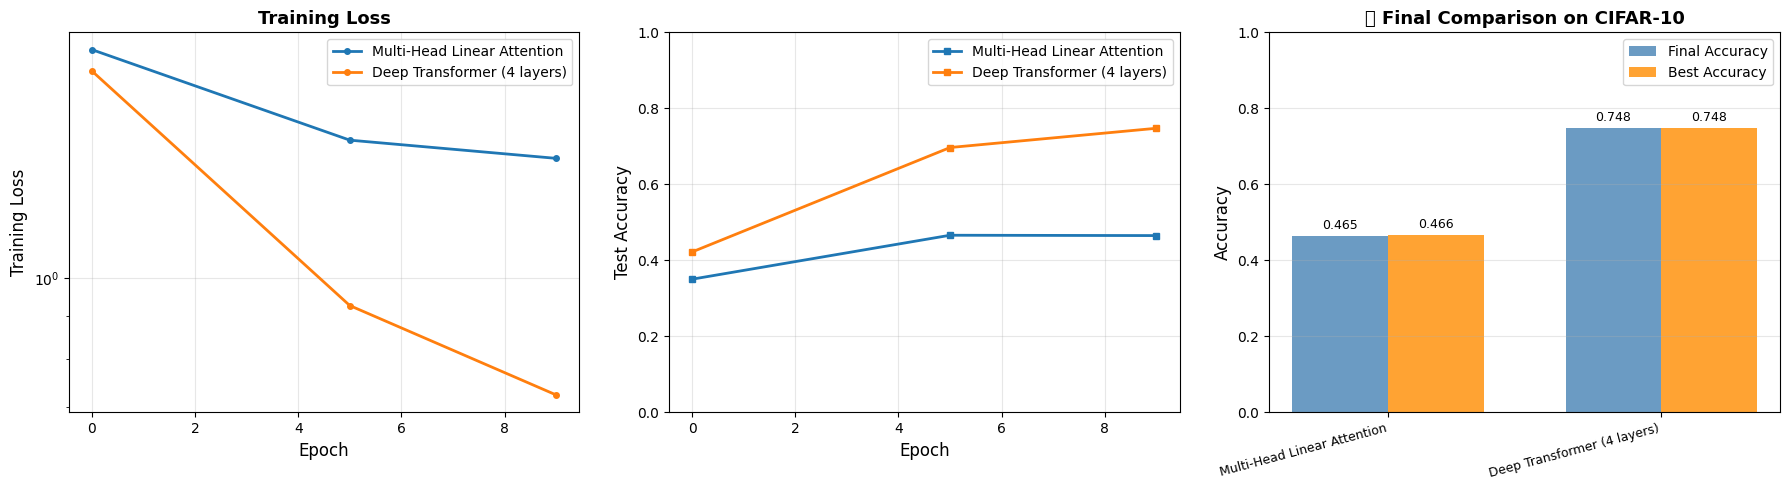

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
for name, data in results.items():
    ax1.plot(data['epochs'], data['train_loss'], label=name, linewidth=2, marker='o', markersize=4)
ax1.set_yscale('log')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for name, data in results.items():
    ax2.plot(data['epochs'], data['test_accuracy'], label=name, linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

ax3 = axes[2]
final_acc = [data['test_accuracy'][-1] if data['test_accuracy'] else 0 for data in results.values()]
best_acc = [max(data['test_accuracy']) if data['test_accuracy'] else 0 for data in results.values()]
model_names = list(results.keys())

x = np.arange(len(model_names))
width = 0.35

bars1 = ax3.bar(x - width/2, final_acc, width, label='Final Accuracy', color='steelblue', alpha=0.8)
bars2 = ax3.bar(x + width/2, best_acc, width, label='Best Accuracy', color='darkorange', alpha=0.8)

ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('🏆 Final Comparison on CIFAR-10', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax3.legend()
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
for name, data in results.items():
    best_acc = max(data['test_accuracy'])
    final_acc = data['test_accuracy'][-1]
    print(f"\n {name}")
    print(f"   Best Test Accuracy:  {best_acc:.4f} ({best_acc*100:.2f}%)")
    print(f"   Final Test Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")


 Multi-Head Linear Attention
   Best Test Accuracy:  0.4659 (46.59%)
   Final Test Accuracy: 0.4650 (46.50%)

 Deep Transformer (4 layers)
   Best Test Accuracy:  0.7475 (74.75%)
   Final Test Accuracy: 0.7475 (74.75%)


ВЫВОД:

Multi‑Head Linear Attention показала низкую точность (≈46,6%), но обучалась много быстрее.

Deep Transformer (4 слоя) достиг лучшего результата (≈74,8%), но обучался очень долго.